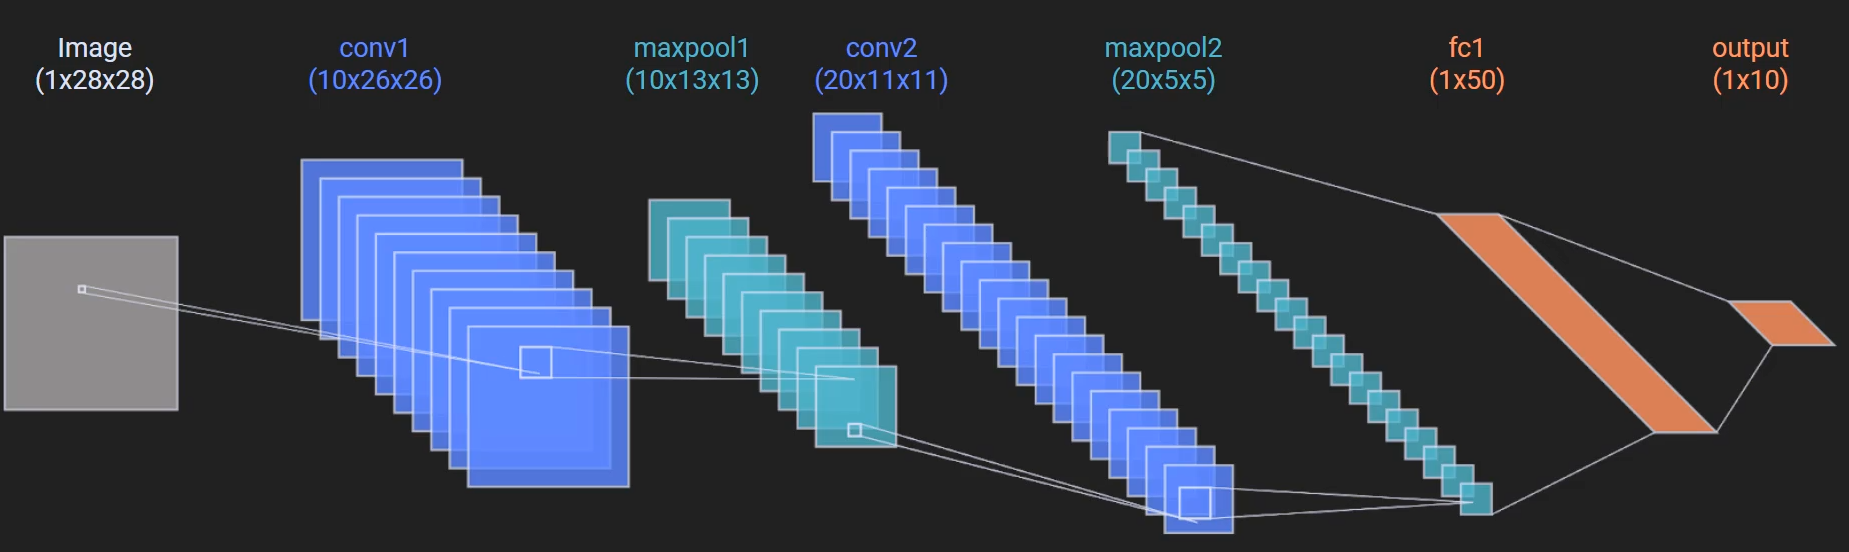

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

In [69]:
data_train = datasets.MNIST(root='data', train=True, download=True, transform=transforms.ToTensor()) 
data_test = datasets.MNIST(root='data', train=False, download=True, transform=transforms.ToTensor())    

# ToTensor(): This transform is lazy. It doesn't overwrite the original data in memory. 
# Instead, it only applies the conversion and scaling (0 to 1) when the data is actually loaded (usually via a DataLoader or by indexing the dataset).
data_train.data.max()

tensor(255, dtype=torch.uint8)

In [70]:
# data_train and data_test are already PyTorch datasets, so we can directly create DataLoaders from them.

batch_size = 32
train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

# check out a sample
images, labels = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(len(train_dataloader), len(test_dataloader))

Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])
1875 313


In [ ]:
class MNIST_CNN(nn.Module):
    def __init__(self, printtoggle=False):
        super().__init__()
    
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5, stride=1, padding=1) # output size = np.floor((28 - 5 + 2*1) / 1) + 1 = 26
    
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # output size = np.floor((26 - 2) / 2) + 1 = 13

        self.conv2 = nn.Conv2d(in_channels=10, out_channels=20, kernel_size=5, stride=1, padding=1) # output size = np.floor((13 - 5 + 2*1) / 1) + 1 = 10 

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # output size = np.floor((10 - 2) / 2) + 1 = 5

        self.fc1 = nn.Linear(in_features=20*5*5, out_features=50)

        self.fc2 = nn.Linear(in_features=50, out_features=10)
        
        self.print = printtoggle # toggl to print the shape of the data at each step

    def forward(self, x):

        print(f"Input shape: {x.shape}") if self.print else None

        # Conv1 -> ReLU -> Pool
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x) # we could also use F.max_pool2d(x, kernel_size=2, stride=2) instead of defining a separate layer for pooling
        print(f"After conv1, relu and pool: {x.shape}") if self.print else None

        # Conv2 -> ReLU -> Pool
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x) # we could also use F.max_pool2d(x, kernel_size=2, stride=2) instead of defining a separate layer for pooling
        print(f"After conv2, relu and pool: {x.shape}") if self.print else None

        # Flatten
        x = x.view(x.shape[0], -1) # flatten the output of the conv layers to feed it to the fully connected layers
        print(f"After flattening: {x.shape}") if self.print else None

        # Fully connected layers
        x = self.fc1(x)
        x = F.relu(x)
        print(f"After fc1 and relu: {x.shape}") if self.print else None

        x = self.fc2(x)
        print(f"After fc2: {x.shape}") if self.print else None
        
        return x
    
model = MNIST_CNN()
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 26, 26]             260
         MaxPool2d-2           [-1, 10, 13, 13]               0
            Conv2d-3           [-1, 20, 11, 11]           5,020
         MaxPool2d-4             [-1, 20, 5, 5]               0
            Linear-5                   [-1, 50]          25,050
            Linear-6                   [-1, 10]             510
Total params: 30,840
Trainable params: 30,840
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.09
Params size (MB): 0.12
Estimated Total Size (MB): 0.21
----------------------------------------------------------------


In [29]:
# test one forward pass to see the print statements in action
model = MNIST_CNN(printtoggle=True)
images, labels = next(iter(train_dataloader))
output = model(images)

Input shape: torch.Size([32, 1, 28, 28])
After conv1, relu and pool: torch.Size([32, 10, 13, 13])
After conv2, relu and pool: torch.Size([32, 20, 5, 5])
After flattening: torch.Size([32, 500])
After fc1 and relu: torch.Size([32, 50])
After fc2: torch.Size([32, 10])


In [ ]:
def train_one_epoch(model: torch.nn.Module,
                    train_dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer):
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    for batch, (X, y) in enumerate(train_dataloader):
        # Forward pass
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        _, predicted = torch.max(y_pred.data, 1)
        train_accuracy += (predicted == y).sum().item() / y.size(0) 
        # we divide by the batch size to get the accuracy for the batch and then we will average it over all batches at the end of the epoch

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_accuracy

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int = 5):
    
    losses_epochs = [] # train losses, we dont need to track test losses cause we are not interested in them for this example
    train_accuracy_epochs = []
    test_accuracy_epochs = []

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_dataloader, loss_fn, optimizer)

        # Calculate average training loss and accuracy for the epoch
        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_acc = train_acc / len(train_dataloader)
        losses_epochs.append(avg_train_loss)
        train_accuracy_epochs.append(avg_train_acc)

        # Evaluate on the test set
        model.eval()
        test_accuracy = 0.0
        with torch.no_grad():
            for X, y in test_dataloader:
                y_pred = model(X)

                _, predicted = torch.max(y_pred.data, 1)
                test_accuracy += (predicted == y).sum().item() / y.size(0)

        avg_test_acc = test_accuracy / len(test_dataloader)
        test_accuracy_epochs.append(avg_test_acc)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Train Accuracy: {avg_train_acc:.4f}, Test Accuracy: {avg_test_acc:.4f}")

    return losses_epochs, train_accuracy_epochs, test_accuracy_epochs

In [30]:
model = MNIST_CNN(printtoggle=False)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
losses, train_accuracy, test_accuracy = train(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Epoch [1/10], Train Loss: 0.2131, Train Accuracy: 0.9346, Test Accuracy: 0.9737
Epoch [2/10], Train Loss: 0.0690, Train Accuracy: 0.9786, Test Accuracy: 0.9831
Epoch [3/10], Train Loss: 0.0488, Train Accuracy: 0.9851, Test Accuracy: 0.9883
Epoch [4/10], Train Loss: 0.0377, Train Accuracy: 0.9881, Test Accuracy: 0.9878
Epoch [5/10], Train Loss: 0.0312, Train Accuracy: 0.9902, Test Accuracy: 0.9903
Epoch [6/10], Train Loss: 0.0268, Train Accuracy: 0.9910, Test Accuracy: 0.9914
Epoch [7/10], Train Loss: 0.0210, Train Accuracy: 0.9937, Test Accuracy: 0.9899
Epoch [8/10], Train Loss: 0.0185, Train Accuracy: 0.9945, Test Accuracy: 0.9903
Epoch [9/10], Train Loss: 0.0158, Train Accuracy: 0.9948, Test Accuracy: 0.9907
Epoch [10/10], Train Loss: 0.0142, Train Accuracy: 0.9955, Test Accuracy: 0.9906


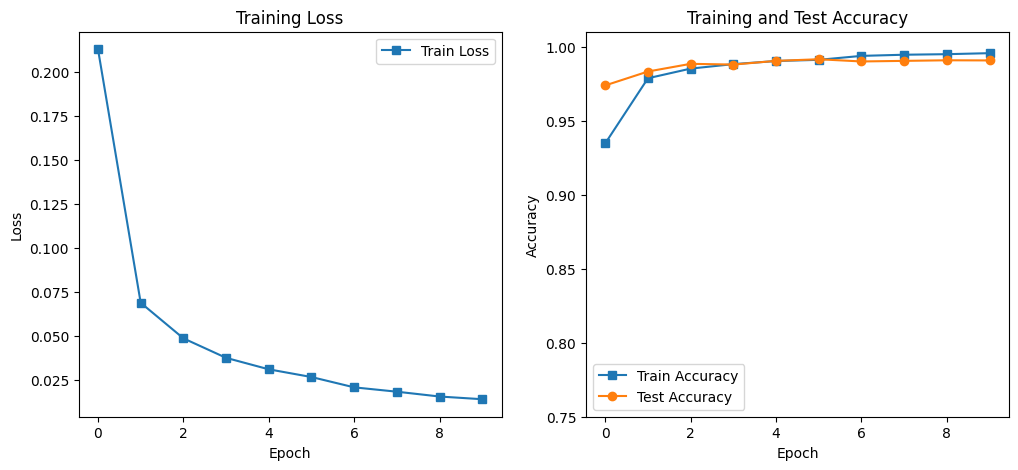

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(losses, "s-", label='Train Loss')
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(train_accuracy, "s-", label='Train Accuracy')
ax[1].plot(test_accuracy, "o-", label='Test Accuracy')
ax[1].set_title("Training and Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0.75, 1.01)
ax[1].legend()

plt.show()

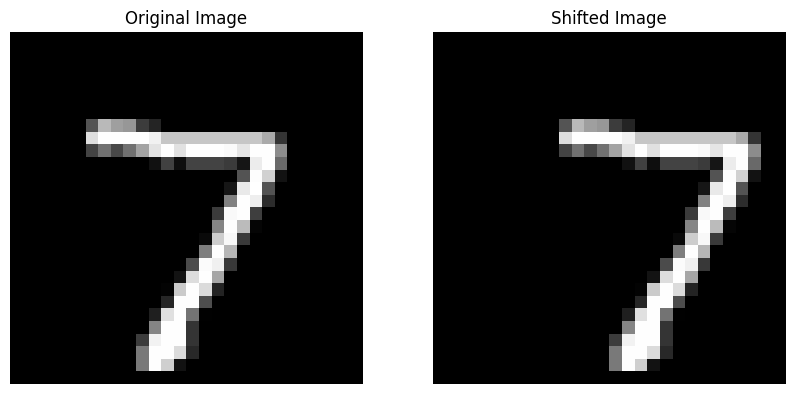

In [71]:
# shift the test images by a few pixels
def shift_images(images, shift):
    shifted_images = torch.zeros_like(images)
    for i in range(images.shape[0]):
        shifted_images[i] = torch.roll(images[i], shifts=shift, dims=2)
    return shifted_images

# now show the original and shifted images side by side
test_images, _ = next(iter(test_dataloader))

shifted_image = shift_images(test_images[0].unsqueeze(0), shift=4) # pick one

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(test_images[0].squeeze(), cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')
ax[1].imshow(shifted_image[0].squeeze(), cmap='gray')
ax[1].set_title("Shifted Image")
ax[1].axis('off')
plt.show()

In [78]:
# now repeat the shift for all images in the training set and put them in a new DataLoader to see how the model performs on shifted images
# for each image we randomly roll it by a different amount between -5 and 5 pixels

all_shifted_images = []
all_labels = []

for images, labels in train_dataloader:

    random_shift = torch.randint(-10, 11, (1,)).item()
    shifted_batch = shift_images(images, shift=random_shift)
    
    all_shifted_images.append(shifted_batch)
    all_labels.append(labels)

# Concatenate all the shifted images and labels into a single tensor
torch_shifted_images = torch.cat(all_shifted_images, dim=0)
torch_labels = torch.cat(all_labels, dim=0)

shifted_dataset = TensorDataset(torch_shifted_images, torch_labels)
shifted_train_dataloader = DataLoader(shifted_dataset, batch_size=batch_size, shuffle=False)

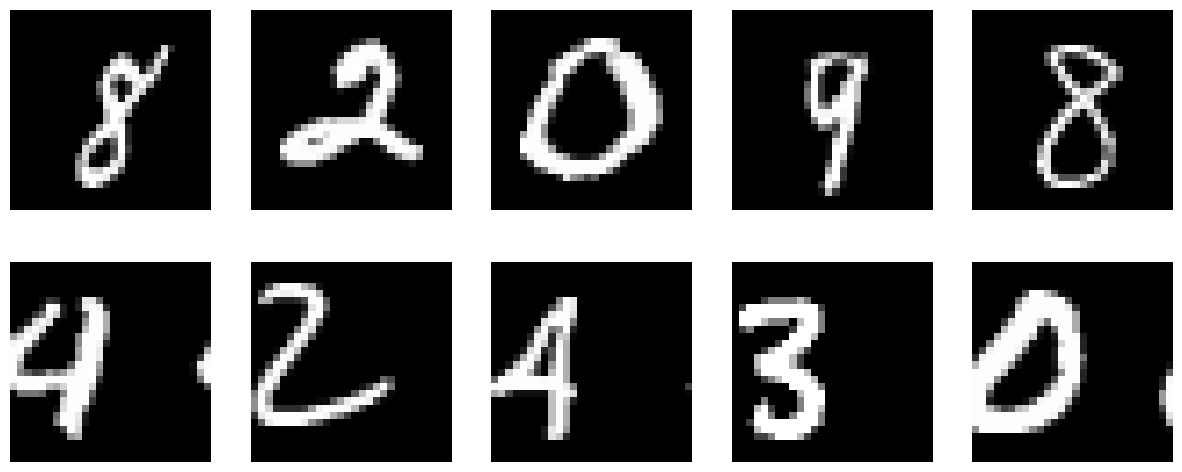

In [82]:
# compare both train loaders by printing a few samples from each
original_images, original_labels = next(iter(train_dataloader))
shifted_images, shifted_labels = next(iter(shifted_train_dataloader))

fig, ax = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    ax[0, i].imshow(original_images[i].squeeze(), cmap='gray')
    ax[0, i].axis('off')

    ax[1, i].imshow(shifted_images[i].squeeze(), cmap='gray')
    ax[1, i].axis('off')
plt.show()

In [83]:
model = MNIST_CNN(printtoggle=False)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
# we just change the train_dataloader
losses, train_accuracy, test_accuracy = train(model, shifted_train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Epoch [1/10], Train Loss: 0.4230, Train Accuracy: 0.8676, Test Accuracy: 0.9561
Epoch [2/10], Train Loss: 0.1452, Train Accuracy: 0.9552, Test Accuracy: 0.9671
Epoch [3/10], Train Loss: 0.1039, Train Accuracy: 0.9685, Test Accuracy: 0.9778
Epoch [4/10], Train Loss: 0.0808, Train Accuracy: 0.9755, Test Accuracy: 0.9813
Epoch [5/10], Train Loss: 0.0644, Train Accuracy: 0.9807, Test Accuracy: 0.9825
Epoch [6/10], Train Loss: 0.0528, Train Accuracy: 0.9836, Test Accuracy: 0.9851
Epoch [7/10], Train Loss: 0.0437, Train Accuracy: 0.9860, Test Accuracy: 0.9833
Epoch [8/10], Train Loss: 0.0369, Train Accuracy: 0.9881, Test Accuracy: 0.9837
Epoch [9/10], Train Loss: 0.0323, Train Accuracy: 0.9897, Test Accuracy: 0.9852
Epoch [10/10], Train Loss: 0.0270, Train Accuracy: 0.9911, Test Accuracy: 0.9836


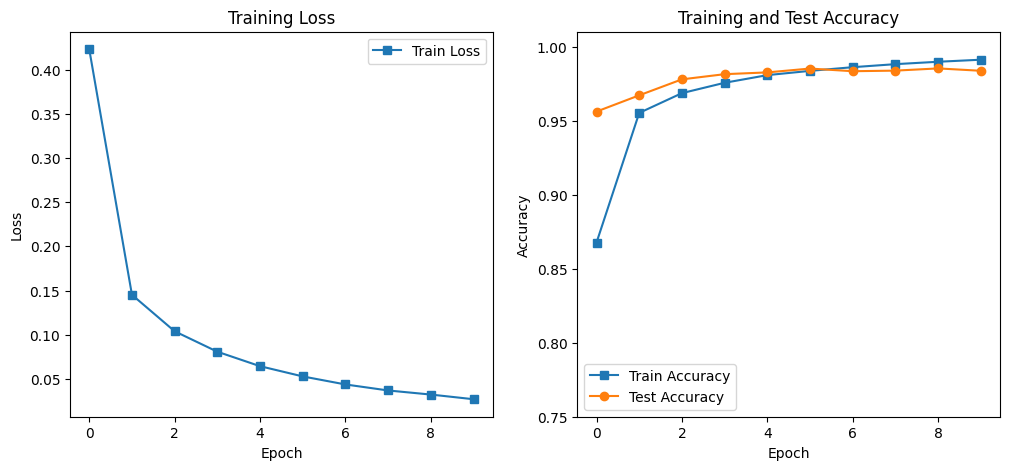

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(losses, "s-", label='Train Loss')
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(train_accuracy, "s-", label='Train Accuracy')
ax[1].plot(test_accuracy, "o-", label='Test Accuracy')
ax[1].set_title("Training and Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0.75, 1.01)
ax[1].legend()

plt.show()

# with a FNN the final test accuracy was around 0.9, with the CNN it is around 0.98, so we can see that the CNN is much more robust to the shift 
# in the images than the FNN. This is because the CNN is able to learn spatial hierarchies of features and is less sensitive to the exact position 
# of the features in the image, while the FNN treats each pixel independently and is more sensitive to changes in pixel positions.